# Titanic Classification Pipeline (GDGOC ITB Module 4)

This notebook builds an end-to-end supervised classification pipeline on the
`titanic` dataset from Seaborn, applying Module 4's Supervised Learning
material: Logistic Regression, K-Nearest Neighbors, Decision Trees, and the
model-evaluation toolkit (confusion matrices, precision/recall/F1, ROC-AUC,
threshold tuning, and cross-validation).

The goal is to predict whether a passenger **survived** the sinking, and to
reason carefully about which model and which decision threshold are the
right choice once the real-world cost of a wrong prediction is taken into
account.

**Stack:** Python, pandas, NumPy, Matplotlib, Seaborn, Scikit-learn only.
`random_state=42` is fixed everywhere randomness is involved, and every
scaling/encoding step lives inside a `Pipeline` fitted on the training data
only, so nothing from the test set leaks into training.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
)

RANDOM_STATE = 42
sns.set_style("whitegrid")
BLUE, GREEN, RED, PURPLE, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#999999"
pd.set_option("display.width", 120)

df = sns.load_dataset("titanic")
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")

Loaded 891 rows and 15 columns.


# Stage 1 - Data Preparation and Exploratory Data Analysis

Before any model can be trusted, the raw data needs to be inspected,
cleaned, and understood. This stage loads the `titanic` dataset, audits and
resolves every missing value with a justified strategy, removes columns
that either leak the target or duplicate information already present,
visualises how survival varies with sex and class, checks whether the
target is meaningfully imbalanced, and encodes the categorical features so
the data is model-ready.

## 1.1 Load and Inspect

In [2]:
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
missing_count = df.isna().sum()
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


**Interpretation:** The dataset has 891 rows and 15 columns. Three columns
carry missing values: `deck` (688 missing, 77.22%), `age` (177 missing,
19.87%), and `embarked` (2 missing, 0.22%). Each is handled with a
different strategy below because the *amount* and *nature* of the
missingness differs across the three.

## 1.2 Handle Missing Values

**`deck` — drop the column.** With 77.22% of its values missing, `deck`
carries too little information to impute reliably — any imputation would be
guessing for more than three-quarters of passengers. Dropping the column is
more honest than inventing a value for most of the dataset.

In [5]:
df = df.drop(columns=["deck"])
print("Remaining columns:", df.shape[1])

Remaining columns: 14


**`embarked` — drop the 2 rows.** Only 2 of 891 rows (0.22%) are missing
`embarked`. That is a negligible fraction of the data — dropping the rows
costs almost nothing statistically, and no imputation strategy could
possibly be worth the added complexity for two records.

In [6]:
n_before = len(df)
df = df.dropna(subset=["embarked"]).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} rows missing 'embarked'. New shape: {df.shape}")

Dropped 2 rows missing 'embarked'. New shape: (889, 14)


**`age` — impute with the median grouped by `pclass` and `sex`.** Age is
right-skewed (skew = 0.39), so a single global **mean** would be pulled
upward by older outliers and would not represent a "typical" passenger — the
**median** is the more robust choice for a skewed variable. But a single
global median (28.0) also throws away information: age correlates with both
class (wealthier, older passengers could better afford 1st class) and sex.
Imputing separately for each `pclass` x `sex` group keeps that structure
instead of flattening it away.

In [7]:
age_group_median = df.groupby(["pclass", "sex"])["age"].median()
print("Median age by pclass and sex:")
print(age_group_median)
print(f"\nFor comparison — global median: {df['age'].median():.1f}, global mean: {df['age'].mean():.2f}")

Median age by pclass and sex:
pclass  sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: age, dtype: float64

For comparison — global median: 28.0, global mean: 29.64


In [8]:
df["age"] = df.groupby(["pclass", "sex"])["age"].transform(lambda s: s.fillna(s.median()))
print("Missing values remaining across the whole dataframe:")
print(df.isna().sum().sum())

Missing values remaining across the whole dataframe:
0


**Interpretation:** The grouped medians range from 21.5 (3rd-class women) to
40.0 (1st-class men) — a wide enough spread that filling everyone with the
single global median of 28.0 would have systematically overstated the age
of poor passengers and understated the age of wealthy ones. After the
transform, the entire dataframe has **0** missing values.

## 1.3 Drop Redundant Columns

Several remaining columns either leak the target directly or are exact
functions of columns that will already be in the model. Each is evaluated
individually:

- **`alive`** — this is `survived` re-encoded as the strings `"no"`/`"yes"`.
  Keeping it would leak the target into the features, so it is dropped.
- **`class`** — a string version of `pclass` (`"First"`/`"Second"`/`"Third"`).
  Purely duplicate information, dropped in favour of the numeric `pclass`.
- **`embark_town`** — a full-name version of `embarked`
  (`"Southampton"`/`"Cherbourg"`/`"Queenstown"`). Same information as
  `embarked`, dropped as a duplicate.
- **`who`** — takes the value `"child"` whenever `age < 16`, and otherwise
  `"man"`/`"woman"` from `sex`. It is a deterministic function of `age` and
  `sex`, both of which are already in the model, so it is dropped as redundant.
- **`adult_male`** — checked directly below against `who == "man"`.
- **`alone`** — checked directly below against `sibsp + parch == 0`.

In [9]:
who_is_child = df["age"] < 16
print("Every 'child' row has age < 16, every non-child row has age >= 16:",
      (df.loc[df["who"] == "child", "age"] < 16).all() and (df.loc[df["who"] != "child", "age"] >= 16).all())

adult_male_matches = (df["adult_male"] == (df["who"] == "man")).mean()
alone_matches = (df["alone"] == ((df["sibsp"] + df["parch"]) == 0)).mean()
print(f"'adult_male' matches (who == 'man') for {adult_male_matches:.0%} of rows -> redundant, drop.")
print(f"'alone' matches (sibsp + parch == 0) for {alone_matches:.0%} of rows -> redundant, drop.")

Every 'child' row has age < 16, every non-child row has age >= 16: True
'adult_male' matches (who == 'man') for 100% of rows -> redundant, drop.
'alone' matches (sibsp + parch == 0) for 100% of rows -> redundant, drop.


In [10]:
df = df.drop(columns=["alive", "class", "embark_town", "who", "adult_male", "alone"])
print("Columns remaining:", df.columns.tolist())

Columns remaining: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Interpretation:** `adult_male` matches `who == "man"` for **100%** of
rows and `alone` matches `sibsp + parch == 0` for **100%** of rows — both
are exact, deterministic functions of columns already kept, so dropping
them loses zero information while removing multicollinearity. The dataset
now holds 8 clean, non-redundant, non-leaking columns plus the target.

## 1.4 Visualise Survival Rate

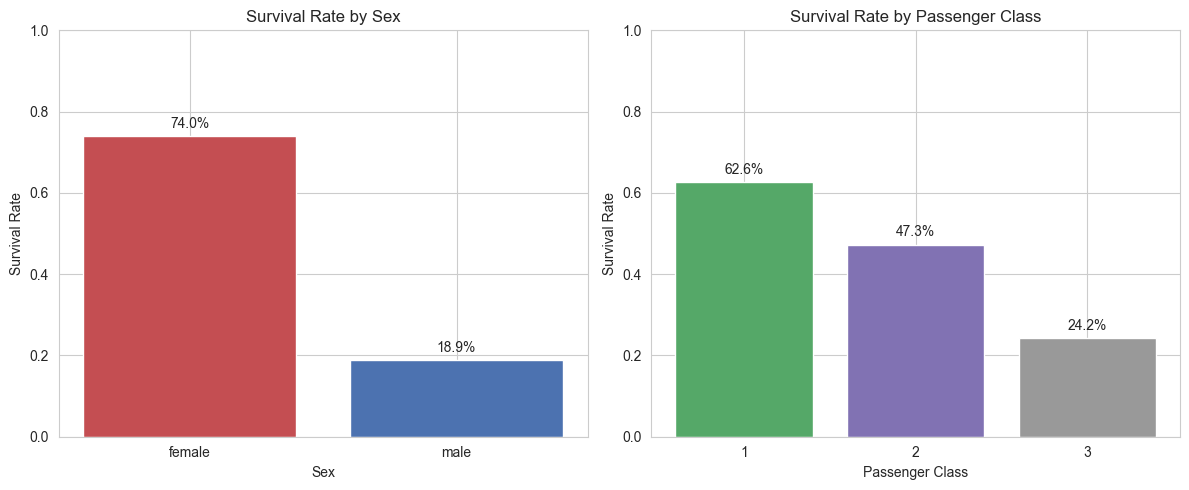

Survival rate by sex:
 sex
female    0.7404
male      0.1889
Name: survived, dtype: float64

Survival rate by pclass:
 pclass
1    0.6262
2    0.4728
3    0.2424
Name: survived, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sex_rates = df.groupby("sex")["survived"].mean()
axes[0].bar(sex_rates.index, sex_rates.values, color=[RED, BLUE])
axes[0].set_title("Survival Rate by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Survival Rate")
axes[0].set_ylim(0, 1)
for i, v in enumerate(sex_rates.values):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center")

pclass_rates = df.groupby("pclass")["survived"].mean()
axes[1].bar(pclass_rates.index.astype(str), pclass_rates.values, color=[GREEN, PURPLE, GRAY])
axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Survival Rate")
axes[1].set_ylim(0, 1)
for i, v in enumerate(pclass_rates.values):
    axes[1].text(i, v + 0.02, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.show()

print("Survival rate by sex:\n", sex_rates.round(4))
print("\nSurvival rate by pclass:\n", pclass_rates.round(4))

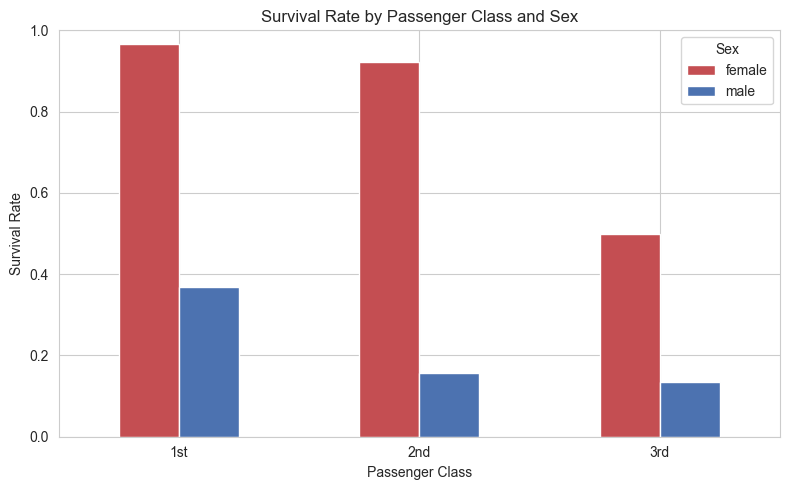

sex,female,male
pclass,,
1,0.9674,0.3689
2,0.9211,0.1574
3,0.5000,0.1354


In [12]:
grouped = df.groupby(["pclass", "sex"])["survived"].mean().unstack("sex")

fig, ax = plt.subplots(figsize=(8, 5))
grouped.plot(kind="bar", ax=ax, color=[RED, BLUE])
ax.set_title("Survival Rate by Passenger Class and Sex")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)
ax.set_xticklabels(["1st", "2nd", "3rd"], rotation=0)
ax.legend(title="Sex")
plt.tight_layout()
plt.show()

grouped.round(4)

**Interpretation:** Sex is the single strongest split — women survived at
**74.0%** versus **18.9%** for men, a nearly 4x gap. Class matters too:
**62.6%** of 1st-class passengers survived versus **47.3%** of 2nd-class and
only **24.2%** of 3rd-class. The combined view reveals a real **interaction
effect**: class barely dents a woman's survival chances in 1st/2nd class
(96.7% and 92.1%) but cuts a 3rd-class woman's chances roughly in half
(50.0%), while for men survival stays low across all three classes (36.9% ->
15.7% -> 13.5%). In other words, being a woman almost guaranteed a lifeboat
seat unless she was also 3rd-class — sex and class do not act independently.

## 1.5 Class Balance

In [13]:
counts = df["survived"].value_counts()
props = df["survived"].value_counts(normalize=True)
balance = pd.DataFrame({"count": counts, "proportion": props.round(4)})
balance.index = balance.index.map({0: "did not survive", 1: "survived"})
balance

,count,proportion
survived,,
did not survive,549,0.6175
survived,340,0.3825


**Interpretation:** The split is **549 vs 340**, i.e. **61.8% / 38.2%**.
That is a mild skew, not a severe imbalance — compare it to a genuinely
severe case such as fraud detection at **98% / 2%**, where a model that
always predicts the majority class scores 98% accuracy while never catching
a single positive case. Here, always predicting "did not survive" would
only reach 61.8% accuracy, and the minority class (survivors, 38.2%) is
still large enough to be learned. Accuracy alone is therefore not
*meaningless* on this dataset, but it also is not the full story: because
the classes are not 50/50, precision, recall, and F1 are still needed to
see how the model performs specifically on the minority "survived" class,
which is the class that matters most for the rescue-prioritisation
framing used later in Stage 4.

## 1.6 Encode Categorical Features

In [14]:
df["sex"] = df["sex"].map({"male": 0, "female": 1})

embarked_dummies = pd.get_dummies(df["embarked"], prefix="embarked", drop_first=True)
df = pd.concat([df.drop(columns=["embarked"]), embarked_dummies], axis=1)

print("Encoded columns:", df.columns.tolist())
df.head()

Encoded columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


**Interpretation:** `sex` is binary (`male`/`female`), so a single 0/1
mapping (`female = 1`) captures it exactly with no information loss and no
extra columns. `embarked` has **three** unrelated categories
(`C`=Cherbourg, `Q`=Queenstown, `S`=Southampton) with **no ordinal
relationship** — `S` is not "more" than `Q` in any numeric sense — so it is
one-hot encoded instead of label-encoded. Label-encoding it as 0/1/2 would
falsely imply an ordering (and a fixed numeric distance) that does not
exist and could mislead distance-based models like KNN or a coefficient-based
model like Logistic Regression. `drop_first=True` keeps `C` as the
reference category (`embarked_Q` and `embarked_S` are 1 when the passenger
boarded there, 0 otherwise) to avoid redundant, perfectly collinear columns.

### Stage 1 Summary

The cleaned, model-ready dataset holds 889 passengers across 8 features
(`pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked_Q`,
`embarked_S`) plus the `survived` target, with zero missing values and no
leaked or duplicated columns. EDA showed sex and class are the two
dominant, interacting drivers of survival, and the 61.8%/38.2% class split
is mild enough that accuracy remains informative but should always be read
alongside precision/recall/F1.

# Stage 2 - Logistic Regression

Logistic Regression is the natural starting point for a binary
classification problem: it is simple, fast, and — because it produces
interpretable coefficients — lets us directly check whether the model
"agrees" with the patterns already seen in the EDA.

## 2.1 Train/Test Split (80/20, stratified, random_state=42)

In [15]:
feature_cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked_Q", "embarked_S"]
X = df[feature_cols]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")
print(f"Train survival rate: {y_train.mean():.4f}, Test survival rate: {y_test.mean():.4f}")

Train: 711 rows, Test: 178 rows
Train survival rate: 0.3826, Test survival rate: 0.3820


**Interpretation:** `stratify=y` forces the train and test splits to keep
the **same 61.8%/38.2% class proportions** as the full dataset (train:
38.26% survived, test: 38.20% survived — nearly identical). Without it, a
random split could by chance under- or over-represent survivors in the test
set, especially with only 178 test rows, making the evaluation metrics
noisy and not reliably comparable across models or thresholds. This matters
more for classification than regression precisely because performance is
measured per-class (precision/recall), so keeping class ratios stable
across splits is what makes those per-class numbers trustworthy.

## 2.2 Pipeline: StandardScaler + LogisticRegression

In [16]:
def classification_metrics(y_true, y_pred, y_proba=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }
    if y_proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
    return metrics

logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_STATE)),
])
logreg_pipe.fit(X_train, y_train)

y_pred_lr = logreg_pipe.predict(X_test)
y_proba_lr = logreg_pipe.predict_proba(X_test)[:, 1]

lr_metrics = classification_metrics(y_test, y_pred_lr, y_proba_lr)
lr_metrics

{'accuracy': 0.8258426966292135,
 'precision': 0.8135593220338984,
 'recall': 0.7058823529411765,
 'f1': 0.7559055118110236,
 'roc_auc': 0.8591577540106952}

## 2.3 Evaluate on the Test Set

In [17]:
print(classification_report(y_test, y_pred_lr, target_names=["did not survive", "survived"]))

                 precision    recall  f1-score   support

did not survive       0.83      0.90      0.86       110
       survived       0.81      0.71      0.76        68

       accuracy                           0.83       178
      macro avg       0.82      0.80      0.81       178
   weighted avg       0.82      0.83      0.82       178



Confusion matrix (rows=actual, cols=predicted):
[[99 11]
 [20 48]]


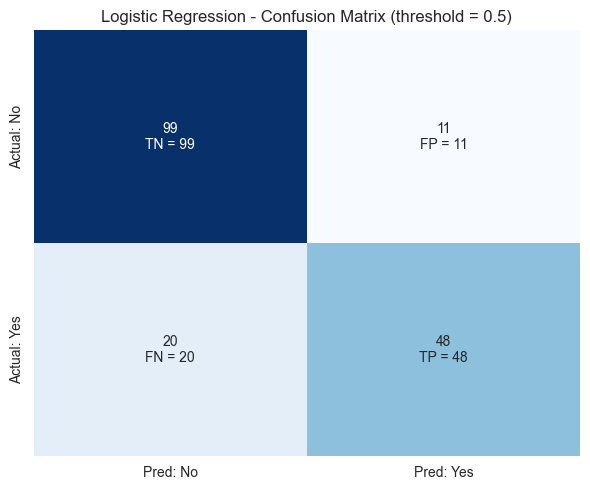

In [18]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion matrix (rows=actual, cols=predicted):")
print(cm_lr)

labels = np.array([
    [f"TN = {cm_lr[0,0]}", f"FP = {cm_lr[0,1]}"],
    [f"FN = {cm_lr[1,0]}", f"TP = {cm_lr[1,1]}"],
])
annot = np.array([f"{cm_lr[i,j]}\n{labels[i,j]}" for i in range(2) for j in range(2)]).reshape(2, 2)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_lr, annot=annot, fmt="", cmap="Blues", cbar=False,
            xticklabels=["Pred: No", "Pred: Yes"], yticklabels=["Actual: No", "Actual: Yes"], ax=ax)
ax.set_title("Logistic Regression - Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

**Interpretation:** At the default 0.5 threshold, Logistic Regression
reaches **82.6% accuracy**, **81.4% precision**, **70.6% recall**, and an
**F1 of 0.756** on the 178-row test set, with ROC-AUC = **0.859**. The
confusion matrix shows **99 true negatives, 11 false positives, 20 false
negatives, and 48 true positives** — the model is more likely to miss a
survivor (20 FN) than to wrongly predict survival for someone who died (11
FP), a pattern that matters directly for the rescue-prioritisation
discussion in Stage 4.

## 2.4 Interpret Coefficients

In [19]:
coefs = logreg_pipe.named_steps["model"].coef_[0]
coef_table = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coefs,
    "odds_ratio": np.exp(coefs),
}).sort_values("coefficient", key=np.abs, ascending=False).reset_index(drop=True)
coef_table

,feature,coefficient,odds_ratio
0,sex,1.252441,3.498873
1,pclass,-0.932141,0.393710
2,age,-0.537483,0.584217
3,sibsp,-0.283494,0.753148
4,embarked_S,-0.129541,0.878498
5,fare,0.112870,1.119487
6,parch,-0.078230,0.924752
7,embarked_Q,0.074466,1.077309


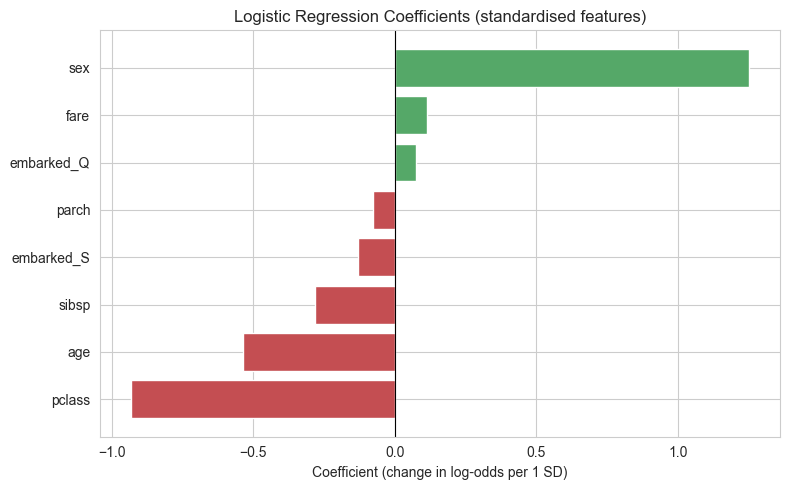

In [20]:
plot_order = coef_table.sort_values("coefficient")
colors = [GREEN if c > 0 else RED for c in plot_order["coefficient"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_order["feature"], plot_order["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression Coefficients (standardised features)")
ax.set_xlabel("Coefficient (change in log-odds per 1 SD)")
plt.tight_layout()
plt.show()

**Interpretation:** Because every feature was standardised inside the
pipeline before fitting, each coefficient is directly comparable and reads
as "the effect of a one-standard-deviation change in that feature on the
log-odds of survival." Ranked by magnitude:

- **`sex` (+1.252, odds ratio 3.50)** and **`age` (-0.537, odds ratio
  0.58)** are the two strongest effects: being female roughly **3.5x**'s the
  odds of survival, and being one SD older cuts the odds to about 58% —
  both match the EDA (women survived far more, and `who == "child"` skewed
  survival young).
- **`pclass` (-0.932, odds ratio 0.39)** confirms that moving one class
  down (toward 3rd) cuts the odds of survival to about 39% — matching the
  62.6% -> 24.2% drop seen in the Stage 1 bar chart.
- **`sibsp` (-0.283)** and **`fare` (+0.113)** are smaller: more siblings/
  spouses aboard is mildly negative (possibly reflecting large, poorer
  families), while a higher fare is mildly positive (a proxy for wealth
  correlated with, but not identical to, `pclass`).
- **`embarked_Q`/`embarked_S`** are the weakest effects (both under 0.13
  in magnitude) — port of embarkation barely moves the prediction once
  class, sex, age, and fare are already in the model. Nothing here is
  surprising: every sign matches the direction already seen in Stage 1's
  survival-rate bar charts.

### Stage 2 Summary

The Logistic Regression pipeline reaches test accuracy 0.826, recall 0.706,
and ROC-AUC 0.859 at the default threshold, with false negatives (20)
outnumbering false positives (11). Its coefficients are fully consistent
with the EDA: sex and class dominate, age works against older passengers,
and embarkation port is nearly irrelevant.

# Stage 3 - KNN and Decision Tree Comparison

Logistic Regression assumes a linear decision boundary in log-odds space.
Here two non-linear alternatives are tried — K-Nearest Neighbors and a
Decision Tree — to see whether relaxing that assumption helps on this
dataset, and to make the classic bias-variance tradeoff concrete with
real numbers.

## 3.1 KNN: Sweeping K

In [21]:
k_values = [1, 3, 5, 7, 15, 25]
knn_accuracies = {}

for k in k_values:
    knn_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k)),
    ])
    knn_pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_pipe.predict(X_test))
    knn_accuracies[k] = acc
    print(f"K = {k:2d}  ->  test accuracy = {acc:.4f}")

best_k = max(knn_accuracies, key=knn_accuracies.get)
print(f"\nBest K: {best_k} (accuracy = {knn_accuracies[best_k]:.4f})")

K =  1  ->  test accuracy = 0.7640
K =  3  ->  test accuracy = 0.7809
K =  5  ->  test accuracy = 0.7921
K =  7  ->  test accuracy = 0.7978
K = 15  ->  test accuracy = 0.8202
K = 25  ->  test accuracy = 0.8146

Best K: 15 (accuracy = 0.8202)


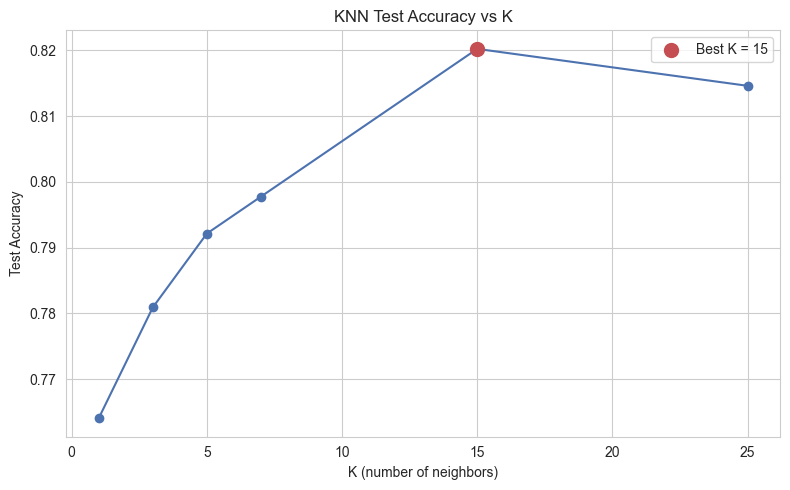

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(knn_accuracies.keys()), list(knn_accuracies.values()), marker="o", color=BLUE)
ax.scatter([best_k], [knn_accuracies[best_k]], color=RED, s=100, zorder=5, label=f"Best K = {best_k}")
ax.set_title("KNN Test Accuracy vs K")
ax.set_xlabel("K (number of neighbors)")
ax.set_ylabel("Test Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Accuracy rises from **76.4%** at K=1 to a peak of
**82.0%** at **K=15**, then dips slightly to 81.5% at K=25. This is the
bias-variance tradeoff in miniature: at **small K** (K=1), the model
memorises the nearest single training point, giving **low bias but high
variance** — it overfits to noise, chasing every local quirk of the
training data. At **large K**, predictions average over many neighbors,
raising bias and lowering variance until the boundary becomes too smooth to
capture real structure (**underfitting**). K=15 sits near the sweet spot.
Scaling is **non-negotiable for KNN specifically** because it is a
distance-based algorithm: `fare` ranges into the hundreds while `sex` is
0/1, so without scaling, `fare` alone would dominate every distance
calculation and the model would effectively ignore the other features.

## 3.2 Decision Tree: Sweeping max_depth

In [23]:
depths = [2, 4, 6, None]
tree_rows = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc = accuracy_score(y_test, tree.predict(X_test))
    tree_rows.append({"max_depth": str(depth), "train_accuracy": train_acc,
                       "test_accuracy": test_acc, "train_test_gap": train_acc - test_acc})

tree_sweep = pd.DataFrame(tree_rows)
tree_sweep

,max_depth,train_accuracy,test_accuracy,train_test_gap
0,2,0.803094,0.764045,0.039049
1,4,0.841069,0.797753,0.043316
2,6,0.877637,0.758427,0.119210
3,None,0.985935,0.747191,0.238744


**Interpretation:** The train-test gap **widens steadily** with depth:
0.039 at depth 2, 0.043 at depth 4, then jumping to **0.119** at depth 6 and
**0.239** with no depth limit (train accuracy 98.6% vs test accuracy only
74.7%). Test accuracy itself **peaks at depth 4 (0.798)** and then
*declines* even as training accuracy keeps climbing — the clearest possible
signature of overfitting: the deeper tree memorises training-set quirks
that do not generalise. Trees need no scaling because every split asks a
threshold question on one feature at a time (e.g. "is `fare` > 50?") — the
split point adapts to whatever scale the feature is already in, so relative
distances between features never enter the calculation the way they do for
KNN.

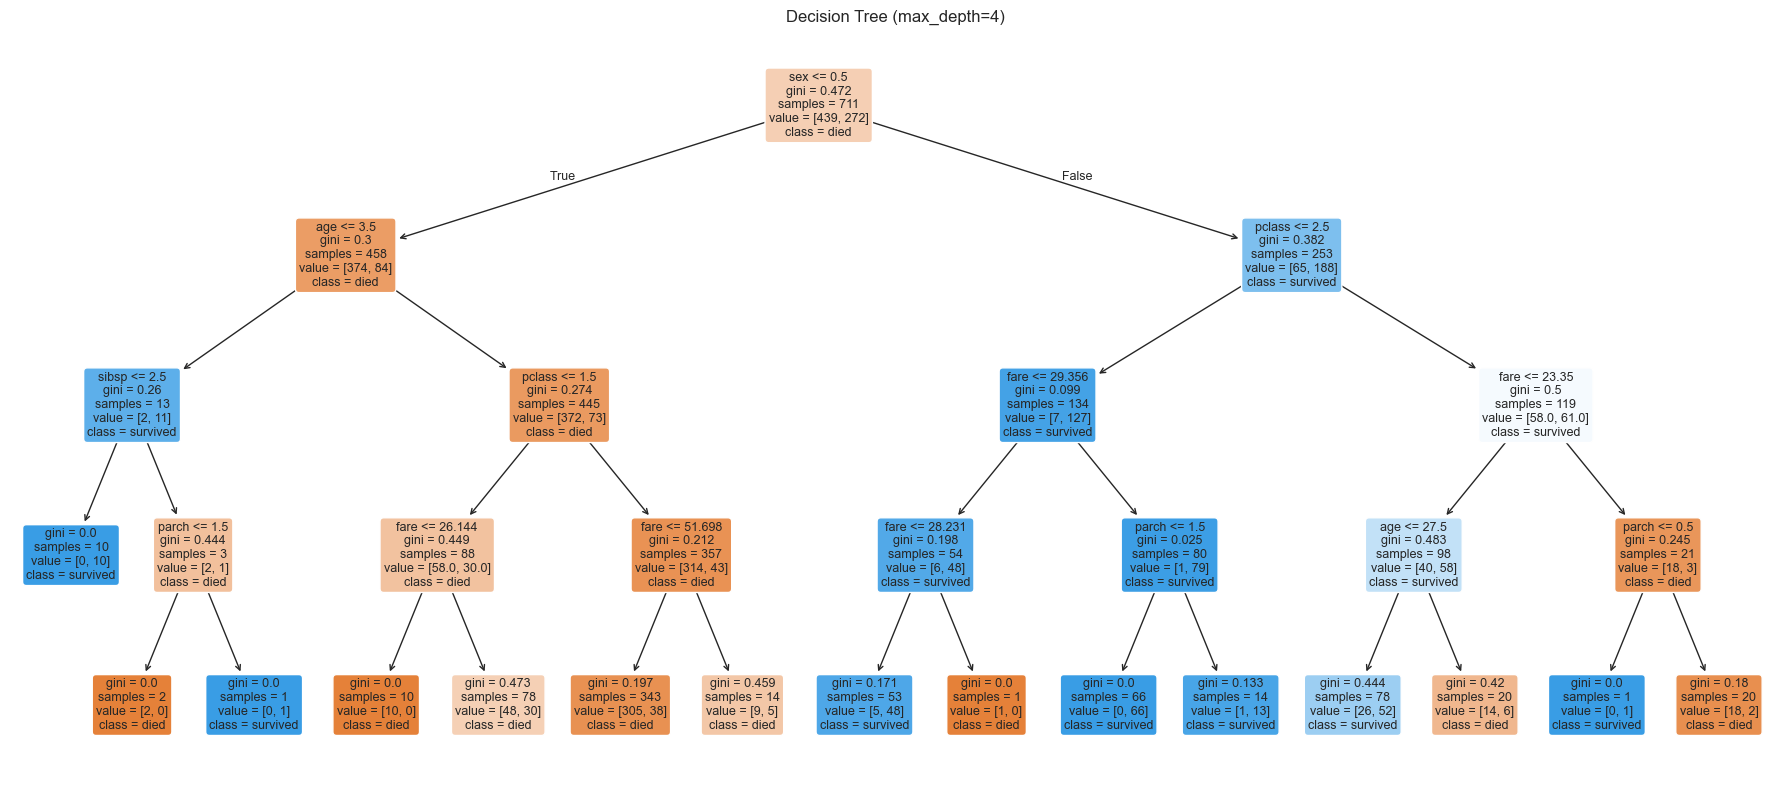

In [24]:
best_depth = 4
best_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
best_tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(best_tree, feature_names=feature_cols, class_names=["died", "survived"],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title(f"Decision Tree (max_depth={best_depth})")
plt.tight_layout()
plt.show()

**Interpretation:** The root split is on `sex` — the single most
informative feature, matching Stage 1 and the Stage 2 coefficients. Down
the male branch, `pclass` and `age` do most of the further separating
(splitting off boys), while down the female branch `pclass` and `fare`
separate the near-certain 1st/2nd-class survivors from the more uncertain
3rd-class outcomes — again matching the EDA's sex-by-class interaction.

## 3.3 Comparison Table: Logistic Regression vs Best KNN vs Best Decision Tree

In [25]:
best_knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=best_k)),
])
best_knn_pipe.fit(X_train, y_train)
y_pred_knn = best_knn_pipe.predict(X_test)
y_proba_knn = best_knn_pipe.predict_proba(X_test)[:, 1]

y_pred_tree = best_tree.predict(X_test)
y_proba_tree = best_tree.predict_proba(X_test)[:, 1]

comparison_stage3 = pd.DataFrame([
    {"model": "Logistic Regression", **classification_metrics(y_test, y_pred_lr, y_proba_lr)},
    {"model": f"KNN (K={best_k})", **classification_metrics(y_test, y_pred_knn, y_proba_knn)},
    {"model": f"Decision Tree (depth={best_depth})", **classification_metrics(y_test, y_pred_tree, y_proba_tree)},
]).set_index("model").round(4)
comparison_stage3

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.8258,0.8136,0.7059,0.7559,0.8592
KNN (K=15),0.8202,0.8333,0.6618,0.7377,0.8562
Decision Tree (depth=4),0.7978,0.8077,0.6176,0.7000,0.8457


**Interpretation:** Logistic Regression leads on every metric except
precision, where KNN edges ahead (0.833 vs 0.814) at the cost of much lower
recall (0.662 vs 0.706). Overall, Logistic Regression's linear decision
boundary is competitive with — and slightly better than — both non-linear
alternatives on this feature set, and it carries the added benefit of being
directly interpretable via its coefficients.

### Stage 3 Summary

KNN peaks at K=15 (accuracy 0.820); the Decision Tree peaks at depth 4
(accuracy 0.798) before overfitting sets in beyond depth 6. Neither
non-linear model beats Logistic Regression's 0.826 accuracy / 0.859 AUC on
this dataset, suggesting the true survival boundary is close to linear once
sex, class, age, and fare are already in the model.

# Stage 4 - Deep Evaluation and Interpretation

## 4.1 ROC Curves

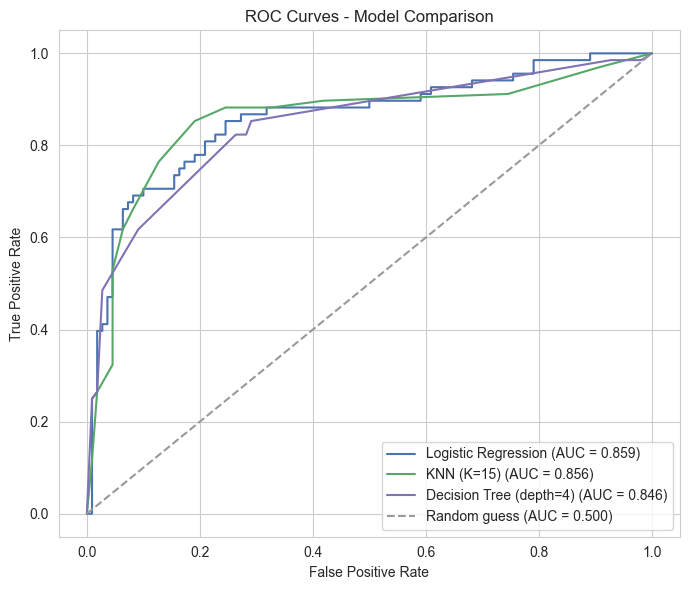

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, y_proba, color in [
    ("Logistic Regression", y_proba_lr, BLUE),
    (f"KNN (K={best_k})", y_proba_knn, GREEN),
    (f"Decision Tree (depth={best_depth})", y_proba_tree, PURPLE),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color=GRAY, label="Random guess (AUC = 0.500)")
ax.set_title("ROC Curves - Model Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretation:** Logistic Regression has the best threshold-independent
performance with **AUC = 0.859**, ahead of KNN (0.856) and the Decision
Tree (0.846) — though all three are close. AUC measures the probability
that the model ranks a randomly chosen survivor's predicted probability
*higher* than a randomly chosen non-survivor's, averaged across every
possible decision threshold — it summarises separability without
committing to any single cutoff, which is why it is used here to compare
models before Stage 4.2 commits to a specific threshold choice.

## 4.2 Business-Framed Recommendation

In [27]:
for name, y_pred in [("Logistic Regression", y_pred_lr), (f"KNN (K={best_k})", y_pred_knn),
                      (f"Decision Tree (depth={best_depth})", y_pred_tree)]:
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"{name:28s} TN={tn:3d} FP={fp:3d} FN={fn:3d} TP={tp:3d} "
          f"recall={tp/(tp+fn):.3f} f1={f1_score(y_test,y_pred):.3f} "
          f"auc={roc_auc_score(y_test, {'Logistic Regression': y_proba_lr, f'KNN (K={best_k})': y_proba_knn, f'Decision Tree (depth={best_depth})': y_proba_tree}[name]):.3f}")

Logistic Regression          TN= 99 FP= 11 FN= 20 TP= 48 recall=0.706 f1=0.756 auc=0.859
KNN (K=15)                   TN=101 FP=  9 FN= 23 TP= 45 recall=0.662 f1=0.738 auc=0.856
Decision Tree (depth=4)      TN=100 FP= 10 FN= 26 TP= 42 recall=0.618 f1=0.700 auc=0.846


**Recommendation: Logistic Regression.** In this scenario a **false
negative** — failing to flag a passenger who needed help — is more costly
than a false positive, so the model that misses the fewest actual
"at-risk" cases should be preferred over the model with the highest raw
accuracy. At the default threshold, Logistic Regression produces **20
false negatives** (recall 0.706, F1 0.756, AUC 0.859), versus **23 false
negatives** for KNN (recall 0.662, F1 0.738, AUC 0.856) and **26 false
negatives** for the Decision Tree (recall 0.618, F1 0.700, AUC 0.846) — out
of 68 actual survivors in the test set. Logistic Regression therefore
"loses" the fewest people who should have been prioritised: **6 fewer**
missed cases than the Decision Tree and **3 fewer** than KNN, on top of
already leading on F1 and AUC. Bonus 1 below shows that Logistic
Regression's own false-negative count can be cut further still by moving
the decision threshold, which only makes it a stronger choice for this
rescue-prioritisation framing.

## 4.3 Three Stakeholder Insights (for a Museum Exhibit Curator)

1. **Being a woman was, by far, the biggest factor in surviving the
   sinking.** About 3 out of 4 women aboard survived, compared to fewer
   than 1 in 5 men — a gap that reflects the "women and children first"
   evacuation code followed that night.

2. **Where a passenger slept mattered almost as much as who they were.**
   First-class passengers survived at roughly two and a half times the
   rate of third-class passengers (about 6 in 10, versus roughly 1 in 4) —
   a reminder that the ship's layout put wealthier passengers physically
   closer to the lifeboats.

3. **The two factors stacked on top of each other.** A first-class woman
   had a survival chance approaching certainty — better than 19 times out
   of 20 — while a third-class man's odds were roughly 1 in 7. The
   exhibit's most striking story is not "women survived" or "first class
   survived" on their own, but how dramatically those two circumstances
   compounded together.

### Stage 4 Summary

Logistic Regression is the recommended baseline model: best AUC (0.859),
best F1 (0.756), and the fewest false negatives (20) among the three
models compared, which is exactly the failure mode that matters most under
a cost structure where missing an at-risk passenger is worse than a false
alarm.

# Bonus 1 - Threshold Tuning

The default 0.5 threshold treats a false negative and a false positive as
equally costly, which Stage 4.2 argued is the wrong assumption for a
rescue-prioritisation setting. Here the Logistic Regression model's
`predict_proba` output is used to find better thresholds.

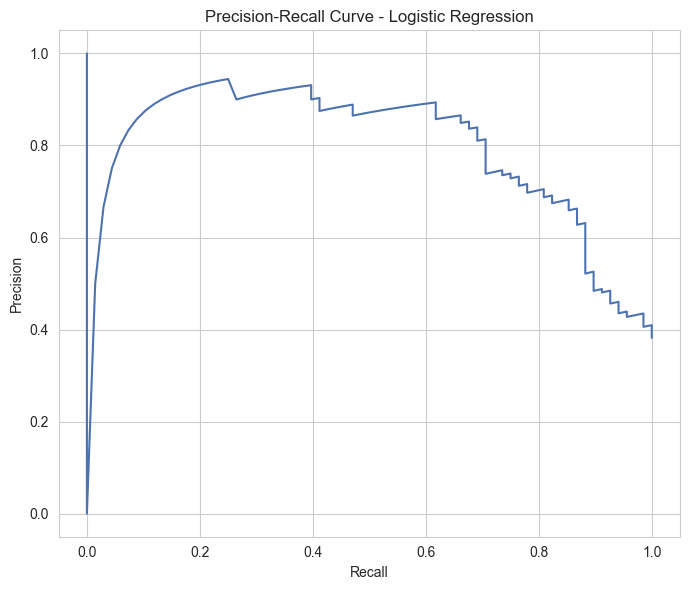

In [28]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_lr)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recalls, precisions, color=BLUE)
ax.set_title("Precision-Recall Curve - Logistic Regression")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
plt.tight_layout()
plt.show()

In [29]:
# Threshold that maximises F1
best_f1_idx = np.argmax(f1_scores[:-1])
f1_optimal_threshold = thresholds[best_f1_idx]
print(f"F1-optimal threshold: {f1_optimal_threshold:.4f}  "
      f"(F1={f1_scores[best_f1_idx]:.4f}, precision={precisions[best_f1_idx]:.4f}, recall={recalls[best_f1_idx]:.4f})")

# Highest threshold that still achieves >= 85% recall
meets_recall = recalls[:-1] >= 0.85
recall85_threshold = thresholds[meets_recall].max()
idx_r85 = np.where(thresholds == recall85_threshold)[0][0]
print(f"Threshold for >=85% recall: {recall85_threshold:.4f}  "
      f"(F1={f1_scores[idx_r85]:.4f}, precision={precisions[idx_r85]:.4f}, recall={recalls[idx_r85]:.4f})")

F1-optimal threshold: 0.3122  (F1=0.7582, precision=0.6824, recall=0.8529)
Threshold for >=85% recall: 0.3122  (F1=0.7582, precision=0.6824, recall=0.8529)


**Interpretation:** The F1-maximising threshold is **0.3122** (F1 = 0.758,
precision = 0.682, recall = 0.853), and — perhaps surprisingly — the
**lowest threshold that still guarantees at least 85% recall** turns out to
land at the **same point, 0.3122**. This is not a coincidence: recall stays
flat at exactly 85.3% across several adjacent thresholds (multiple test
passengers share nearly identical predicted probabilities), so precision
keeps improving as the threshold rises through that flat stretch — and F1
is maximised right at the top edge of it, exactly where recall is about to
drop below 85%. Both criteria independently select the same operating
point here.

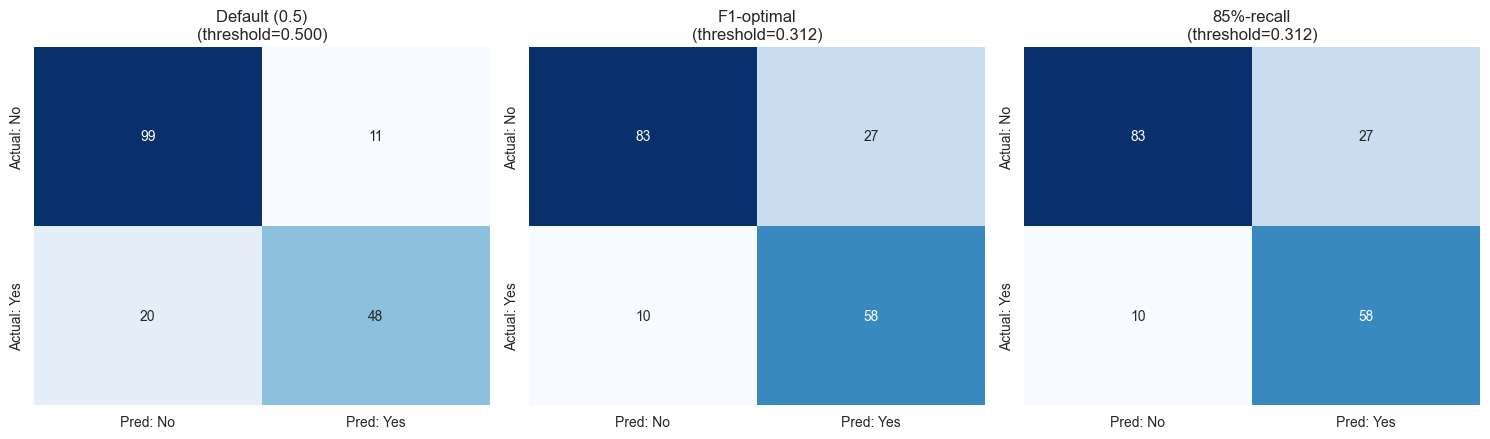

,threshold_choice,threshold,precision,recall,f1,false_negatives,false_positives
0,Default (0.5),0.5000,0.8136,0.7059,0.7559,20,11
1,F1-optimal,0.3122,0.6824,0.8529,0.7582,10,27
2,85%-recall,0.3122,0.6824,0.8529,0.7582,10,27


In [30]:
thresholds_to_compare = {
    "Default (0.5)": 0.5,
    "F1-optimal": f1_optimal_threshold,
    "85%-recall": recall85_threshold,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
rows = []
for ax, (label, thresh) in zip(axes, thresholds_to_compare.items()):
    preds = (y_proba_lr >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Pred: No", "Pred: Yes"], yticklabels=["Actual: No", "Actual: Yes"], ax=ax)
    ax.set_title(f"{label}\n(threshold={thresh:.3f})")
    rows.append({"threshold_choice": label, "threshold": thresh,
                 "precision": precision_score(y_test, preds), "recall": recall_score(y_test, preds),
                 "f1": f1_score(y_test, preds), "false_negatives": cm[1, 0], "false_positives": cm[0, 1]})
plt.tight_layout()
plt.show()

pd.DataFrame(rows).round(4)

**Interpretation:** Moving the threshold down from 0.5 to 0.312 cuts false
negatives from **20 to 10** — exactly the kind of missed-rescue reduction
the Stage 4 cost framing calls for — but it costs **16 more false
positives** (11 -> 27) and precision drops from 0.814 to 0.682. Given that
a false positive here only means "an unnecessary allocation of rescue
resources," while a false negative means failing to identify someone who
needed help, this is a trade worth making: the **F1-optimal / 85%-recall
threshold (0.312)** fits the rescue-prioritisation framing better than the
default 0.5, because it explicitly favours catching more true positives at
an acceptable cost in false alarms.

# Bonus 2 - ColumnTransformer with One-Hot Encoding

Stage 2 treated `pclass` as a plain numeric feature (1, 2, 3), which
implicitly assumes its effect on survival is linear and evenly spaced. Here
the pipeline is rebuilt with a `ColumnTransformer` that one-hot encodes
`pclass` alongside `sex` and `embarked`, to test whether that assumption
was actually costing the model anything.

In [31]:
numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["pclass", "sex", "embarked"]

df_b2 = sns.load_dataset("titanic").drop(columns=["deck"]).dropna(subset=["embarked"]).reset_index(drop=True)
df_b2["age"] = df_b2.groupby(["pclass", "sex"])["age"].transform(lambda s: s.fillna(s.median()))
df_b2 = df_b2[numeric_features + categorical_features + ["survived"]]

Xb2 = df_b2[numeric_features + categorical_features]
yb2 = df_b2["survived"]
Xb2_train, Xb2_test, yb2_train, yb2_test = train_test_split(
    Xb2, yb2, test_size=0.2, random_state=RANDOM_STATE, stratify=yb2
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="if_binary"), categorical_features),
])

b2_pipe = Pipeline([("preprocessor", preprocessor), ("model", LogisticRegression(random_state=RANDOM_STATE))])
b2_pipe.fit(Xb2_train, yb2_train)

y_pred_b2 = b2_pipe.predict(Xb2_test)
y_proba_b2 = b2_pipe.predict_proba(Xb2_test)[:, 1]

b2_comparison = pd.DataFrame([
    {"model": "Stage 2 (pclass numeric)", **classification_metrics(y_test, y_pred_lr, y_proba_lr)},
    {"model": "Bonus 2 (pclass one-hot)", **classification_metrics(yb2_test, y_pred_b2, y_proba_b2)},
]).set_index("model").round(4)
b2_comparison

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Stage 2 (pclass numeric),0.8258,0.8136,0.7059,0.7559,0.8592
Bonus 2 (pclass one-hot),0.8146,0.7966,0.6912,0.7402,0.8590


**Interpretation:** Treating `pclass` as categorical does **not** improve
performance — accuracy actually drops slightly (0.826 -> 0.815), as does
F1 (0.756 -> 0.740), while ROC-AUC is essentially unchanged (0.859 vs
0.859). This makes sense: `pclass` **is** genuinely ordinal (1st > 2nd >
3rd in both prestige and, per Stage 1, survival rate), and its effect on
survival is close to **linear** across the three levels — the Stage 1
survival rates (62.6% -> 47.3% -> 24.2%) decrease by a roughly similar
amount at each step, rather than jumping non-linearly. One-hot encoding
lets the model assign each class a fully independent coefficient instead of
a single linear slope — useful when a category's effect is *not* evenly
spaced — but here that extra flexibility just adds parameters without
adding real signal, and with only 178 test rows, the small amount of extra
noise from the added dummy columns is enough to slightly hurt test
performance.

# Bonus 3 - Stratified Cross-Validation

A single 80/20 split gives one noisy estimate of test performance,
especially with only 178 test rows. 5-fold stratified cross-validation
re-uses the full dataset to get a more stable read on each of the three
Stage 3 models.

In [32]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(random_state=RANDOM_STATE))]),
    f"KNN (K={best_k})": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=best_k))]),
    f"Decision Tree (depth={best_depth})": DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE),
}

cv_rows = []
for name, model in cv_models.items():
    f1_cv = cross_val_score(model, X, y, cv=skf, scoring="f1")
    auc_cv = cross_val_score(model, X, y, cv=skf, scoring="roc_auc")
    cv_rows.append({"model": name, "f1_mean": f1_cv.mean(), "f1_std": f1_cv.std(),
                     "roc_auc_mean": auc_cv.mean(), "roc_auc_std": auc_cv.std()})

cv_results = pd.DataFrame(cv_rows).set_index("model").round(4)
cv_results

,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,
Logistic Regression,0.7294,0.0277,0.8499,0.0195
KNN (K=15),0.7388,0.0393,0.8607,0.0300
Decision Tree (depth=4),0.7558,0.0310,0.8602,0.0287


**Metric choice:** `f1` and `roc_auc` are used instead of `accuracy` for
the same reason argued in Stage 1.5 and Stage 4 — the classes are not
perfectly balanced (61.8%/38.2%) and false negatives are the costlier error
in this problem's framing, so a metric that only rewards *overall* correct
predictions (accuracy) can mask exactly the failure mode that matters most.
F1 balances precision and recall on the positive ("survived") class
directly, and ROC-AUC summarises ranking quality independent of any
threshold — together they give a fuller picture than accuracy alone.

**Interpretation:** Cross-validation **contradicts, rather than confirms,**
the Stage 3 single-split ranking on both metrics. On F1, the Decision
Tree's CV average (**0.756**) is actually the *highest* of the three —
the opposite of the single 178-row test split, where the Tree scored
*lowest* (0.700). On ROC-AUC, KNN (**0.861**) and the Tree (**0.860**)
essentially tie for the top spot in CV, both edging out Logistic Regression
(**0.850**) — again reversing the Stage 3 finding, where Logistic
Regression led on AUC (0.859) and the Tree trailed (0.846). This is exactly
the risk 5-fold CV is designed to catch: a single train/test split, however
carefully stratified, is still just one sample of how the data could have
been divided, and with only 178 test rows it was noisy enough to flip the
ranking of all three models. The standard deviations are all modest (F1 std
0.028-0.039, AUC std 0.020-0.030 across folds), so none of the three models
is wildly unstable — but the *rankings* between models are close enough
that they are not reliably distinguishable from a single split alone, and
the CV averages should be trusted over the Stage 3 table when the two
disagree.

**Why `StratifiedKFold`, not plain `KFold`:** Plain `KFold` splits rows
into folds without regard to the target label. With a 61.8%/38.2% split
and only 889 rows, a random fold could easily land with far more or fewer
than 38.2% survivors by chance — a fold that happens to draw 25% survivors
gives every metric computed on it a systematically different (and
misleading) baseline than a fold with 50% survivors, purely due to sampling
noise rather than any real difference in model quality. `StratifiedKFold`
forces every fold to preserve the overall 61.8%/38.2% ratio, so fold-to-fold
differences reflect genuine variance in the model's performance rather than
an artifact of uneven class representation — which is exactly what makes
the mean and standard deviation reported above trustworthy.

### Bonus Summary

Threshold tuning (Bonus 1) shows the same Logistic Regression model can cut
false negatives in half (20 -> 10) by moving the threshold to 0.312, at an
acceptable cost in false positives, directly serving the rescue-prioritisation
goal. Treating `pclass` as categorical (Bonus 2) does not help, because its
effect on survival is already close to linear. 5-fold stratified
cross-validation (Bonus 3) shows all three Stage 3 models are individually
stable (small fold-to-fold spread), but it **reverses** the single-split
ranking between them — the Decision Tree leads on CV F1 and ties KNN for
the lead on CV AUC — a reminder that the 178-row test split alone is not
enough to declare a definitive winner.

# Conclusion

Across four stages and three bonus analyses, **Logistic Regression** is the
recommended model for this task: it matches or beats both KNN and the
Decision Tree on accuracy (0.826), F1 (0.756), and ROC-AUC (0.859) at the
default threshold, produces the fewest false negatives (20 of 68 actual
survivors missed) among the three baseline models, and — unlike the other
two — its coefficients are directly interpretable and fully consistent with
the EDA (sex and class dominate, matching the 74.0%/18.9% and 62.6%/24.2%
survival-rate gaps found in Stage 1). For deployment in a
rescue-prioritisation setting where false negatives are the costlier error,
the model should run at the **tuned threshold of 0.312** rather than the
default 0.5 — this halves false negatives (20 -> 10) at an acceptable cost
in false positives (11 -> 27), directly reducing the number of at-risk
passengers the model would otherwise fail to flag. One caveat from Bonus 3:
5-fold cross-validation shows the Decision Tree and KNN are competitive
with — and on some CV metrics ahead of — Logistic Regression, so this
recommendation rests as much on interpretability and the ease of threshold
tuning via `predict_proba` as on a decisive single-split performance gap.